In [2]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

# Pfad hinzufügen, damit wir als Modul importieren können
sys.path.append(os.path.abspath('..'))

from python.disco import DiSCo

In [3]:
dube = pd.read_csv('../dube_full_data/dube_combined.csv')

In [4]:
dube_80 = dube[dube['age'] < 80].copy()

In [5]:
from python.swasserstein import project_and_sort_distribution
import torch

# Nur das Jahr 2013 zum Testen verwenden
dube_80_2013 = dube_80[dube_80['year'] == 2013].copy()

# Bereinige die Features ggf. von NaN-Werten vor der Tensor-Operation
dube_80_clean = dube_80_2013.dropna(subset=['adj0contpov', 'age']).copy()

# Features definieren
features = ['adj0contpov', 'age']

# Projektion auf 100 Slices anwenden
n_slices = 1000
result = project_and_sort_distribution(df=dube_80_clean,
                                       features=features,
                                       n_slices=n_slices,
                                       sort_output=True)

projected_data = result['projected_data']
directions = result['directions']

print(f"Projected Data Shape: {projected_data.shape} -> (N, L)")
print(f"Directions Shape: {directions.shape} -> (d, L)")

# Die ersten 5 projizierten Werte der ersten Projektion ansehen (sortiert)
print("\nErste 5 Werte des ersten Slices:")
print(projected_data[:5, 0])

Projected Data Shape: torch.Size([589536, 1000]) -> (N, L)
Directions Shape: torch.Size([2, 1000]) -> (d, L)

Erste 5 Werte des ersten Slices:
tensor([0., 0., 0., 0., 0.])


<Axes: >

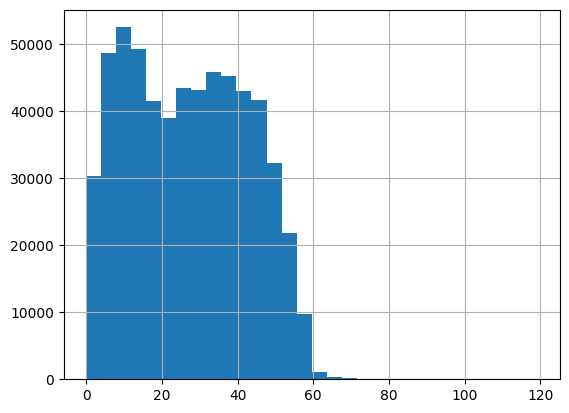

In [6]:
dube_80_clean['projection'] = projected_data[:, 0]
dube_80_clean['projection'].hist(bins=30)

In [7]:

data = []
for fips, group in dube_80_clean.groupby('fips'):
    group = group.sample(frac=1, random_state=42) # Shuffle
    mid = len(group) // 2
    
    # Pre-treatment (z.B. Jahr 1)
    pre = group.iloc[:mid].copy()
    pre['year'] = 1
    
    # Post-treatment (z.B. Jahr 2)
    post = group.iloc[mid:].copy()
    post['year'] = 2
    
    data.extend([pre, post])

dube_synth = pd.concat(data, ignore_index=True)
dube_synth.head()

,year,fips,adj0contpov,age,projection
0,1,1,0.000000,71,0.588976
1,1,1,14.588785,19,35.777027
2,1,1,1.674341,49,35.739674
3,1,1,4.274892,22,0.333923
4,1,1,5.568239,62,0.000000


In [53]:
fit_projection = DiSCo(
    df=dube_synth,
    id_col='fips',
    time_col='year',
    y_col='projection',
    id_col_target=26,     # FIPS = 26 (Michigan) als Treatment
    t0=2,                   # Treatment im Jahr 2 (post-treatment)
    M=1000,              # Monte Carlo Draws 
    G=1000,              # Grid Size
    num_cores=-1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=True,
    perm=False,
    seed=None,
    cl=0.99,
)
fit_projection = fit_projection.fit()

In [49]:
fit_income = DiSCo(
    df=dube_synth,
    id_col='fips',
    time_col='year',
    y_col='adj0contpov',
    id_col_target=26,     # FIPS = 26 (Michigan) als Treatment
    t0=2,                   # Treatment im Jahr 2 (post-treatment)
    M=1000,              # Monte Carlo Draws 
    G=1000,              # Grid Size
    num_cores=-1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=True,
    perm=False,
    seed=None,
    cl=0.99,
)
fit_income = fit_income.fit()

In [33]:
dube_synth.loc[dube_synth['fips'] == 8, 'projection'].apply(lambda x: round(x)).value_counts()

projection
4     4398
20    3055
38    2800
39    1598
21    1343
Name: count, dtype: int64

In [51]:
pd.Series(fit_income.results_periods[2].DiSCo.weights, 
          index=fit_income.control_ids).sort_values(ascending=False).head(10)

20    2.332545e-01
2     1.979317e-01
50    1.518684e-01
44    1.462821e-01
39    1.263736e-01
22    5.676643e-02
40    5.024012e-02
24    3.124143e-02
28    6.041612e-03
51    3.152509e-17
dtype: float64

In [54]:
pd.Series(fit_projection.results_periods[2].DiSCo.weights, 
          index=fit_projection.control_ids).sort_values(ascending=False).head(10)

16    6.659404e-01
38    1.220083e-01
51    1.045205e-01
42    6.071628e-02
48    2.141416e-02
44    1.343785e-02
36    1.196261e-02
50    5.896328e-16
28    4.807295e-16
37    2.721545e-16
dtype: float64

In [11]:
def plot_fit_quantiles(fit_synth, show_controls=False, period=None):    
    periods = sorted(list(fit_synth.results_periods.keys()))
    if period is None:
        # Default to the last period (usually post-treatment)
        period = periods[-1]
        
    period_res = fit_synth.results_periods[period]
    x_grid = fit_synth.evgrid
    target_quantiles = period_res.target.quantiles
    disco_quantiles = period_res.DiSCo.quantile

    plt.figure(figsize=(6, 5))
    plt.plot(x_grid, target_quantiles, color='black', linewidth=3, label='Target')
    plt.plot(x_grid, disco_quantiles, color='red', linewidth=3, label='DSC')
    
    if hasattr(fit_synth, 'CI') and fit_synth.CI is not None and hasattr(fit_synth.CI, 'quantile') and fit_synth.CI.quantile is not None:
        period_idx = periods.index(period)
        lower = fit_synth.CI.quantile.lower[:, period_idx]
        upper = fit_synth.CI.quantile.upper[:, period_idx]
        # x_grid hinzufügen für korrekte Ausrichtung auf der X-Achse
        plt.plot(x_grid, lower, color='red', linewidth=1, linestyle='--', label='CI (DSC)')
        plt.plot(x_grid, upper, color='red', linewidth=1, linestyle='--')

    if show_controls:
        for i in range(period_res.controls.quantiles.shape[1]):
            control_quantiles = period_res.controls.quantiles[:,i]
            plt.plot(x_grid, control_quantiles, color='grey', linewidth=1,linestyle = '--' , label=f'Controls' if i == 0 else None)

    plt.xlim(-0.02, 1.02)
    plt.xlabel('x', fontsize=14)
    plt.ylabel('$F^{-1}(x)$', fontsize=14)
    plt.legend(loc='lower right', frameon=True, edgecolor='black', framealpha=1, borderpad=1, fontsize=12)

    # Adding the border around the axis as seen in the R plot
    plt.gca().spines['top'].set_visible(True)
    plt.gca().spines['right'].set_visible(True)
    plt.gca().spines['bottom'].set_visible(True)
    plt.gca().spines['left'].set_visible(True)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.tight_layout()
    plt.grid(linestyle='--', alpha=0.5)

    plt.show()

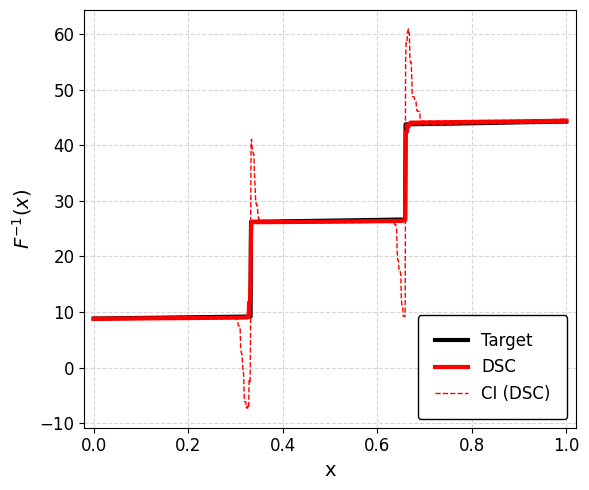

In [12]:
plot_fit_quantiles(fit_dube, show_controls=False)